In [1]:
import lightning_vocoders
from transformers import Wav2Vec2FeatureExtractor, AutoModel
from lightning_vocoders.models.hifigan.lightning_module import HiFiGANLightningModule
import librosa
import torch
import numpy as np

In [2]:
processor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-large")
src = AutoModel.from_pretrained("microsoft/wavlm-large").to(0)
tgt = HiFiGANLightningModule.load_from_checkpoint(
    lightning_vocoders.MODEL_URLS["wavlm-large"], map_location="cpu").to(0)

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
def _get_audio(path):
    x, _ = librosa.load(path, sr=16000, mono=True)
    return x

def _get_feats(x):
    x_norm = processor(raw_speech=[x], sampling_rate=16000, padding=False, return_tensors="pt")
    outputs = src(**{k: t.to(0) for k, t in x_norm.items()})
    return outputs.last_hidden_state.to(0)

def _synth_audio(feats):
    x_hat = tgt.generator(feats)
    x_hat = x_hat.to("cpu").flatten().detach().numpy()
    return x_hat

In [4]:
import parselmouth
from parselmouth.praat import call

def _get_f1_f2(audio, t):
    snd = parselmouth.Sound(values=audio, sampling_frequency=16000)
    formant = snd.to_formant_burg(time_step=0.04)  # 10 ms time step (optional)
    f1 = formant.get_value_at_time(1, t)  # Formant 1 at time t
    f2 = formant.get_value_at_time(2, t)  # Formant 2 at time t
    return f1, f2

In [5]:
audio_l = _get_audio("../data/interpolation_demo_samples_all/consonants/bar-par/bar-par_ALPHA=0.0.wav")
audio_r = _get_audio("../data/interpolation_demo_samples_all/consonants/bar-par/bar-par_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/consonants/dall-tall/dall-tall_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/consonants/dall-tall/dall-tall_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/consonants/tell-sell/tell-sell_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/consonants/tell-sell/tell-sell_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/consonants/tell-sell/tell-sell_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/consonants/pig-ping/pig-ping_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/vowels/li-lu/li-lu_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/vowels/li-lu/li-lu_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/vowels/ti-tu/ti-tu_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/vowels/ti-tu/ti-tu_ALPHA=1.0.wav")

# audio_l = _get_audio("../data/interpolation_demo_samples_all/vowels/te-ti/te-ti_ALPHA=0.0.wav")
# audio_r = _get_audio("../data/interpolation_demo_samples_all/vowels/te-ti/te-ti_ALPHA=1.0.wav")

feats_l = _get_feats(audio_l)
feats_r = _get_feats(audio_r)

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/torch/nn/functional.py:4999: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


GT


Synthesized


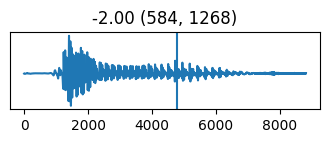

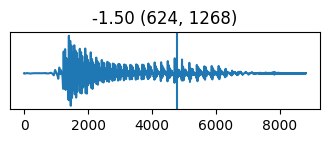

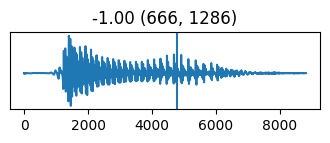

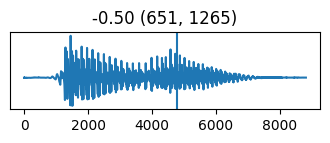

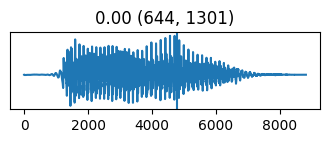

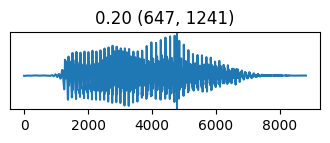

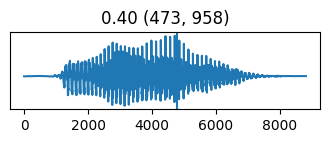

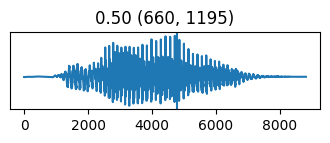

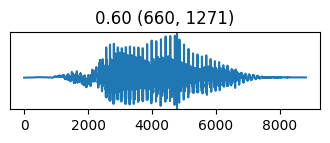

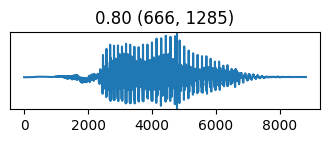

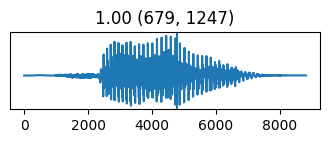

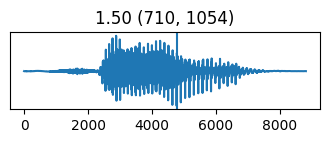

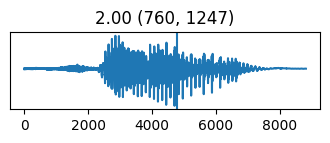

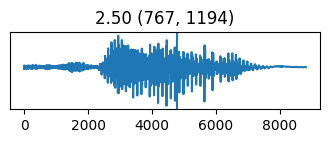

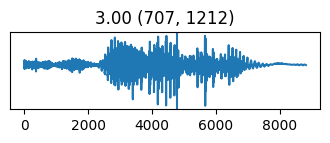

In [6]:
from IPython.display import Audio, display
import matplotlib.pyplot as plt

print("GT")
display(Audio(audio_l, rate=16000))
display(Audio(audio_r, rate=16000))

print("Synthesized")
# for alpha in np.linspace(0, 1, 11):
for alpha in [-2, -1.5, -1, -0.5, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1, 1.5, 2, 2.5, 3]:
    # print(f"{alpha:.2f}")
    audio = _synth_audio(feats_l * (1.0 - alpha) + feats_r * alpha)

    t = 0.3
    f1, f2 = _get_f1_f2(audio, t)

    plt.figure(figsize=(4, 1))
    # plt.title(f"{alpha:.2f}")
    plt.title(f"{alpha:.2f} ({int(f1)}, {int(f2)})")
    plt.yticks([])
    plt.plot(audio)
    plt.axvline(16000 * t)
    plt.show()
    
    display(Audio(audio, rate=16000))
